In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import torch
import numpy as np

print(f"PyTorch Version: {torch.__version__}")

# 1. The Divine Fire: Checking if the GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

print("\n--- NumPy vs PyTorch Practice ---")

# 2. Creating a 2D array in NumPy (something you know)
np_array = np.array([[1.0, 2.0], [3.0, 4.0]])




















print(f"NumPy Array:\n{np_array} (Type: {type(np_array)})")

# 3. Forging a PyTorch Tensor from that NumPy array
py_tensor = torch.from_numpy(np_array)
print(f"PyTorch Tensor:\n{py_tensor} (Type: {type(py_tensor)})")

# 4. Sending your tensor to the GPU warrior
if torch.cuda.is_available():
    gpu_tensor = py_tensor.to(device)
    print(f"\nTensor successfully sent to GPU! Device property: {gpu_tensor.device}")

PyTorch Version: 2.11.0+cu128
Using device: cuda
GPU Model: Tesla T4

--- NumPy vs PyTorch Practice ---
NumPy Array:
[[1. 2.]
 [3. 4.]] (Type: <class 'numpy.ndarray'>)
PyTorch Tensor:
tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64) (Type: <class 'torch.Tensor'>)

Tensor successfully sent to GPU! Device property: cuda:0


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        # input: (none, 28, 28) -> flatten -> (None, 784) [784 is 28*28 so]
        self.flatten = nn.Flatten()

        #  hidden layer main(initial): (None, 784) ->(None, 16)
        self.fc_initial = nn.Linear(784, 16)

        # left side branch

        # first hidden layer left: (None, 16) -> (None, 8)
        self.fc_left_1 = nn.Linear(16, 8)
        # second hidden layer left: (None, 8) -> (None, 8)
        self.fc_left_2 = nn.Linear(8, 8)

        # right  side branch

        # first hidden layer right: (None, 16) -> (None, 12)
        self.fc_right_1 = nn.Linear(16, 12)
        # second hidden layer right : (None, 12) -> (None, 8)
        self.fc_right_2 = nn.Linear(12, 8)

        # Output Layer:(None, 16)->(None, 10)
        self.fc_out = nn.Linear(16, 10)

    def forward(self, x):
        # Flatten
        x = self.flatten(x)
        #pass through main initial layer
        x = F.relu(self.fc_initial(x))

        # left branch processing
        left_1_out = F.relu(self.fc_left_1(x))
        left_2_out = F.relu(self.fc_left_2(left_1_out))
        # skip connection add:(None, 8), (None, 8) ->Out (None, 8)
        left_branch_final = left_1_out + left_2_out

        # right branch
        right_1_out = F.relu(self.fc_right_1(x))
        right_branch_final = F.relu(self.fc_right_2(right_1_out))

        # concatenate both branches    (None, 8), (None, 8) -> Out (None, 16
        # dim=1 concatenates along the feature dimension
        concant_out = torch.cat((left_branch_final, right_branch_final), dim=1)

        # final layer(output)
        outp = self.fc_out(F.relu(concant_out))
        return outp

MOdel=MLP().to(device)
print(MOdel)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc_initial): Linear(in_features=784, out_features=16, bias=True)
  (fc_left_1): Linear(in_features=16, out_features=8, bias=True)
  (fc_left_2): Linear(in_features=8, out_features=8, bias=True)
  (fc_right_1): Linear(in_features=16, out_features=12, bias=True)
  (fc_right_2): Linear(in_features=12, out_features=8, bias=True)
  (fc_out): Linear(in_features=16, out_features=10, bias=True)
)


# BUILDING THE MODEL

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 167kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.14MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.11MB/s]


mean of dataset:0.2860405743122101 std of dataset:0.3530242443084717
total no of training images: 60000
total no of testing images: 10000
number of training batches with 64 image per batch: 938


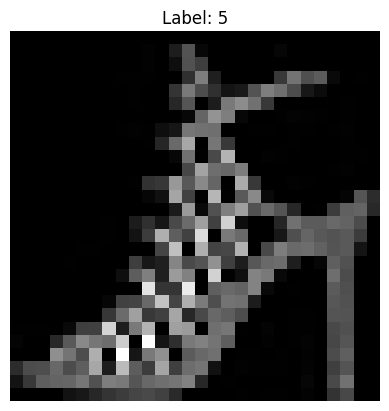

In [4]:
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plot
import numpy as np

#1. extracting the mean and std of the Fashion MNIST dataset
raw_data=torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
data=raw_data.data.float()/255.00
datamean=data.mean().item()
datasd=data.std().item()
print("mean of dataset:"+str(datamean),"std of dataset:"+str(datasd))

#they represent the global average pixel intensity and the spread of those intensities across the entire dataset when scaled to a [0, 1] range.



# 2. formatting the data and transforming it so that images can be fed in as data (Transforms)
# Neural networks prefer numbers clustered around 0 rather than large ranges (0-255 pixels).
transform = transforms.Compose([
    transforms.ToTensor(), # first step,converts the images to tensors(each pixel is now between 0 and 1)
    transforms.Normalize((datamean,), (datasd,)) # second step ,normalises(centres the data) mean=0.5,sd=0.5
])#(each pixel is now between -1 and 1),(x-mean)/sd,z-score
#without compose we have to manually apply this to every image.

# 2.downloading and seperating the training and testing FASHION -  MNIST data
# train=True gets the training set, train=False gets the test set
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)#root=data saves the images in the folder called data in the kaagle notebook
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)#from step 1,we bring in the transform


# 3. batching, as the loading the gpu with all the data at once reduces the effiency,gpu sits idle for most of the time.can lead to crashes.
# We feed the network 64 images at a time instead of all 60,000 at once to save memory and improve effiency.
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)#we shuffle the data to remove biases towards an one value,batch size is 64,at once 64 4d tensors are sent to the gpu
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)#no shuffling for testing

print(f"total no of training images: {len(train_set)}")
print(f"total no of testing images: {len(test_set)}")
print(f"number of training batches with 64 image per batch: {len(train_loader)}")

# 4. visualizing a single batch
dataiter = iter(train_loader)#we made an iterable object ,we don't need to display all images so we didn;t use for loop
images, labels = next(dataiter)#we pushed the first object up

# un-normalize and displaying the first image of the batch
img = (images[0] *datasd) + datamean
plot.imshow(np.squeeze(img.numpy()), cmap='gray')
#.numpy() changes pytorch tensorse back to numpy arrays,squeeze squeezes the 3d format to 2d(removes the dimension of 1) for plotting

plot.title(f"Label: {labels[0].item()}")#.item extracts the integer label value and displayes it,else it will be displayed as tenson(integer)
plot.axis('off')
plot.show()

# EXTRACTING THE DATA

--- Beginning of Training (Training the model) ---
  [Epoch 1, Batch 300] Loss: 0.912
  [Epoch 1, Batch 600] Loss: 0.513
  [Epoch 1, Batch 900] Loss: 0.466
Epoch [1/3] | Train Loss: 0.6222, Train Acc: 78.02% | Val Loss: 0.4698, Val Acc: 83.36%
  [Epoch 2, Batch 300] Loss: 0.436
  [Epoch 2, Batch 600] Loss: 0.418
  [Epoch 2, Batch 900] Loss: 0.415
Epoch [2/3] | Train Loss: 0.4218, Train Acc: 84.81% | Val Loss: 0.4310, Val Acc: 84.40%
  [Epoch 3, Batch 300] Loss: 0.403
  [Epoch 3, Batch 600] Loss: 0.383
  [Epoch 3, Batch 900] Loss: 0.386
Epoch [3/3] | Train Loss: 0.3900, Train Acc: 86.07% | Val Loss: 0.4092, Val Acc: 85.17%
--- Training Completed ---


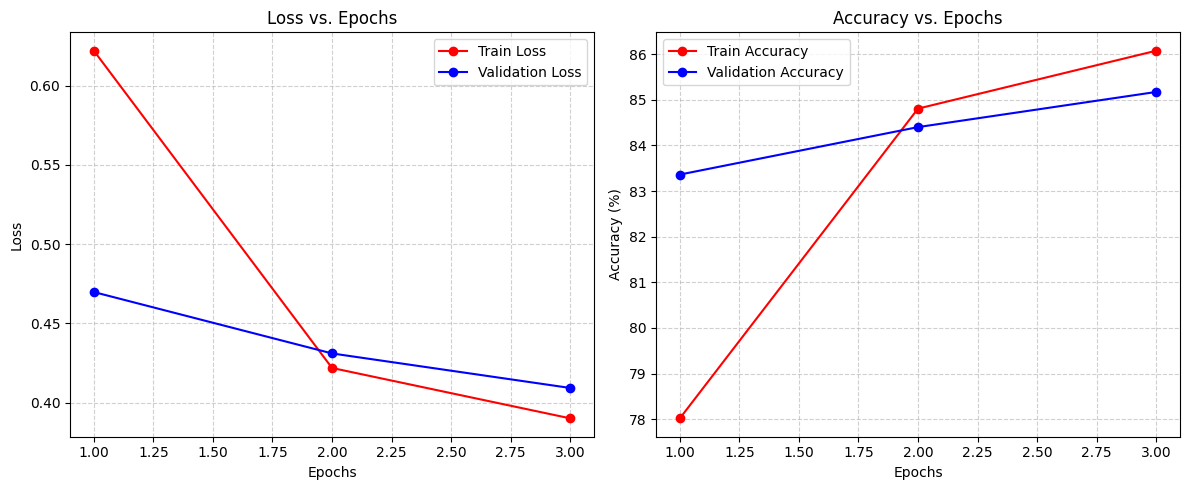

In [5]:
#  Baseline Training
import torch.optim as optim
loss_history=[]
train_acc_history = []
val_loss_history = []
val_acc_history = []
batch_loss_history=[]

# 1.Loss Function and Optimizer
# CrossEntropyLoss is standard for multi-class classification (digits 0-9)
criterion = nn.CrossEntropyLoss()#softmax(e^x by summation e^x)+negative-log-likelihood
#loss=- summation(ytrue*log(pmodel)),,,loss=-log(pcorrect)

# Adam is a highly efficient optimizer that dynamically adjusts the learning rate
optimizer = optim.Adam(MOdel.parameters(), lr=0.001)#lr=learning rate

# 2.Training Loop

#An Epoch is one complete pass through the entire library of 60,000 images,we run it 3 times because looking at the data just once isn't enough to memorize the complex patterns
epochs=3
print("--- Beginning of Training (Training the model) ---")
for epoch in range(3):
    MOdel.train() # Set the model to training mode
    running_loss = 0.0
    correct_train=0
    total_train=0
    running_batch_loss=0.0

    for i, (inputs, labels) in enumerate(train_loader):#batch numbers,images,answers
        # Moving the batched data to  GPU
        inputs, labels = inputs.to(device), labels.to(device)

        # Step 1: Clear the old gradients from the last step
        optimizer.zero_grad()

        # Step 2: forward pass (make blind guess)
        outputs = MOdel(inputs)

        # Step 3: Calculate the loss (How wrong was the prediction?)
        loss = criterion(outputs, labels)

        # Step 4: Backward Pass (Calculate the gradients),backpropagation
        loss.backward()

        # Step 5: Optimize (Update the models weights)
        optimizer.step()

        running_loss += loss.item()
        running_batch_loss += loss.item()
        if i % 300 == 299:
            print(f"  [Epoch {epoch + 1}, Batch {i + 1}] Loss: {running_batch_loss / 300:.3f}")
            batch_loss_history.append(running_batch_loss / 300)
            running_batch_loss = 0.0

        # calculating training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # calculating average loss and accuracy for the epoch
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct_train / total_train

    loss_history.append(epoch_train_loss)
    train_acc_history.append(epoch_train_acc)


# --- VALIDATION PHASE ---
    MOdel.eval() # Set model to evaluation mode
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    # torch.no_grad() disables gradient calculation to save memory and compute
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = MOdel(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            # Calculate Validation Accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(test_loader)
    epoch_val_acc = 100 * correct_val / total_val

    val_loss_history.append(epoch_val_loss)
    val_acc_history.append(epoch_val_acc)

    # Print metrics for the epoch
    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")



print("--- Training Completed ---")

# 3. Plotting Results against Epochs
epochs_range = range(1, epochs + 1)

# Plot Loss
plot.figure(figsize=(12, 5))
plot.subplot(1, 2, 1)
plot.plot(epochs_range, loss_history, label='Train Loss', color='red', marker='o')
plot.plot(epochs_range, val_loss_history, label='Validation Loss', color='blue', marker='o')
plot.title('Loss vs. Epochs')
plot.xlabel('Epochs')
plot.ylabel('Loss')
plot.legend()
plot.grid(True, linestyle='--', alpha=0.6)

# Plot Accuracy
plot.subplot(1, 2, 2)
plot.plot(epochs_range, train_acc_history, label='Train Accuracy', color='red', marker='o')
plot.plot(epochs_range, val_acc_history, label='Validation Accuracy', color='blue', marker='o')
plot.title('Accuracy vs. Epochs')
plot.xlabel('Epochs')
plot.ylabel('Accuracy (%)')
plot.legend()
plot.grid(True, linestyle='--', alpha=0.6)

plot.tight_layout()
plot.show()

# TRAINING AND VALIDATION

In [6]:


print("--- Generating the submission.csv file ---")
MOdel.eval()
predictions = []


with torch.no_grad():#as we are testing the model,this helps us in saving memory and increases comp speed
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = MOdel(inputs)

        # Get the predicted class (the index with the highest probability)
        _, predicted_classes = torch.max(outputs, 1)#we dont need the actual numerical value,so _

        # Move predictions back to CPU and convert to a standard python list
        predictions.extend(predicted_classes.cpu().numpy())


# 'Id' column and a 'Label' column
submission = pd.DataFrame({
    'Id': range(len(predictions)),
    'Label': predictions
})

# Export to CSV without the index column
submission.to_csv('submission.csv', index=False)
print("Successfully saved predictions to submission.csv")

--- Generating the submission.csv file ---
Successfully saved predictions to submission.csv


# .csv file for test predictions

In [7]:
import pickle

# 1. Extracting the state dictionary of model containing all the weights and biases
model_weights = MOdel.state_dict()

# 2. new file  is opened in write-binary ('wb') mode
with open('model_weights.pkl', 'wb') as f:
    pickle.dump(model_weights, f)

print("Model weights successfully saved to model_weights.pkl file")

Model weights successfully saved to model_weights.pkl file


# Model weights saved using pickle